# Sales Data Cleaning and Visualization Project

Objective:
Clean a raw dataset, handle missing values, detect outliers, and create visualizations to extract insights.

Tools Used:
Python, Pandas, Matplotlib, Seaborn

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

print("Libraries Loaded")

Libraries Loaded


# Load Dataset

In [3]:
df = pd.read_csv(r"C:\Users\moham\OneDrive\Desktop\data_science_project\data/tips.csv")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# Data Understanding

In [4]:
df.shape #shape of dataset

(244, 7)

In [5]:
df.columns #columns present in dataset

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='object')

In [6]:
df.info() #data types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [8]:
df.describe() #summary

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


# Check Missing Values

In [9]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

In [13]:
df.ffill(inplace=True) #fill the missing value

# Check for duplicates

In [14]:
df.duplicated().sum()

np.int64(1)

In [15]:
df.drop_duplicates(inplace=True) #if duplicated exists delete them

# Detect Outliers using boxplots

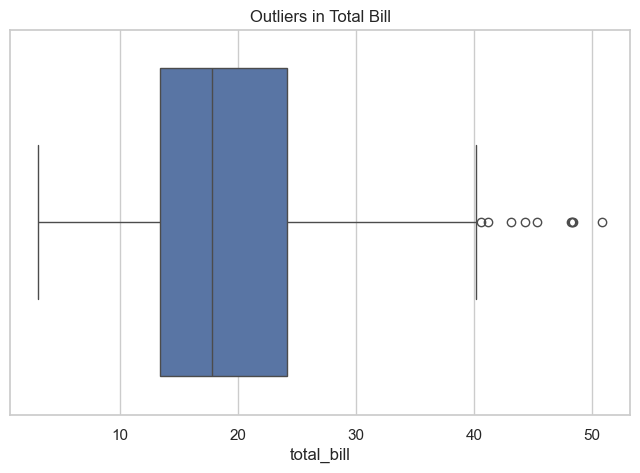

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["total_bill"])
plt.title("Outliers in Total Bill")
plt.show()

In [17]:
Q1 = df["total_bill"].quantile(0.25)
Q3 = df["total_bill"].quantile(0.75)
IQR = Q3 - Q1
df = df[(df["total_bill"] >= Q1 - 1.5*IQR) &
        (df["total_bill"] <= Q3 + 1.5*IQR)] #remove outliers

# Data Visualization

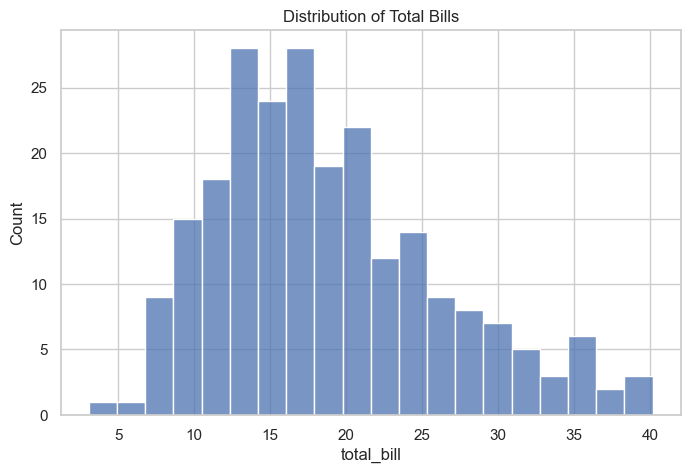

In [18]:
#bill distribution using histograms
plt.figure(figsize=(8,5))
sns.histplot(df["total_bill"], bins=20)
plt.title("Distribution of Total Bills")
plt.show()

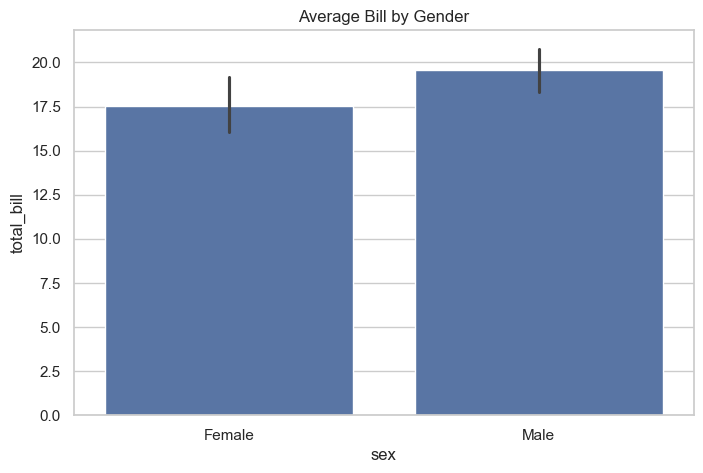

In [19]:
#gender vs spending using bargraph
plt.figure(figsize=(8,5))
sns.barplot(x="sex", y="total_bill", data=df)
plt.title("Average Bill by Gender")
plt.show()

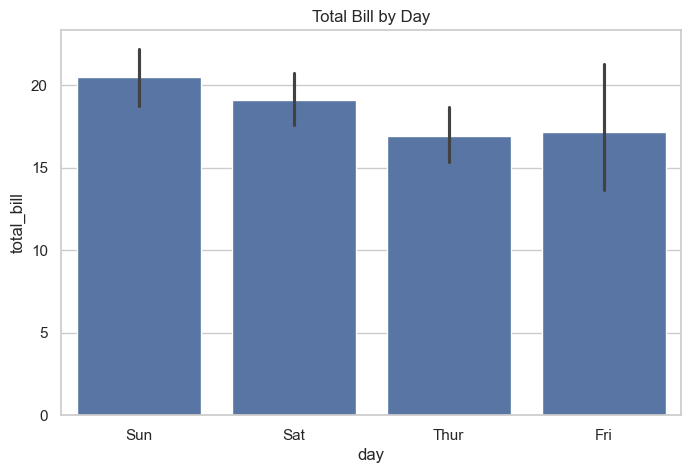

In [20]:
#revenue vs day using bargraph
plt.figure(figsize=(8,5))
sns.barplot(x="day", y="total_bill", data=df)
plt.title("Total Bill by Day")
plt.show()

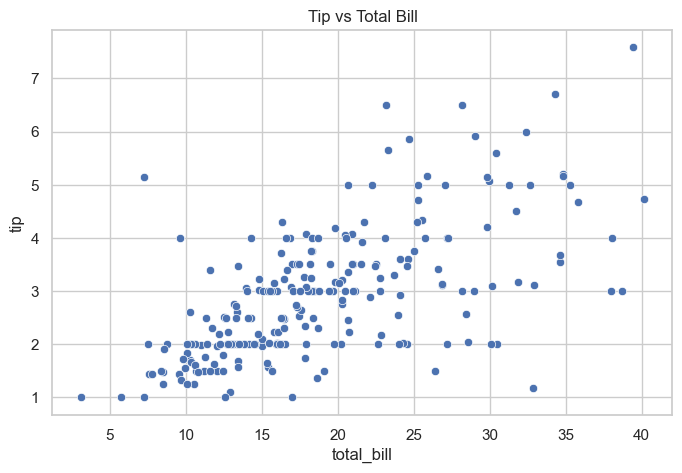

In [21]:
#tp vs bill using scatter plot
plt.figure(figsize=(8,5))
sns.scatterplot(x="total_bill", y="tip", data=df)
plt.title("Tip vs Total Bill")
plt.show()

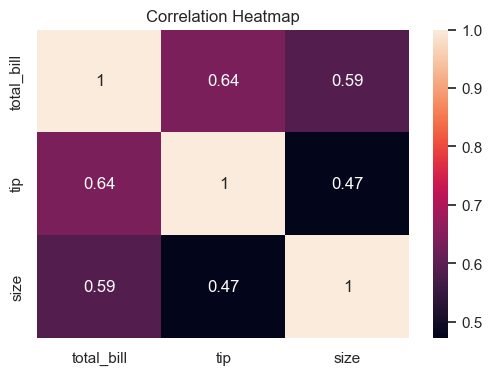

In [22]:
#heatmap for correlation
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

# Key Insights

1. Total bill and tip are positively correlated.
2. Weekend days show higher spending.
3. Male customers have slightly higher average bills.
4. Higher bills usually result in larger tips.

# Save Clean Dataset

In [23]:
df.to_csv(r"C:\Users\moham\OneDrive\Desktop\data_science_project\data/cleaned_tips.csv", index=False)

# Save Visualizations

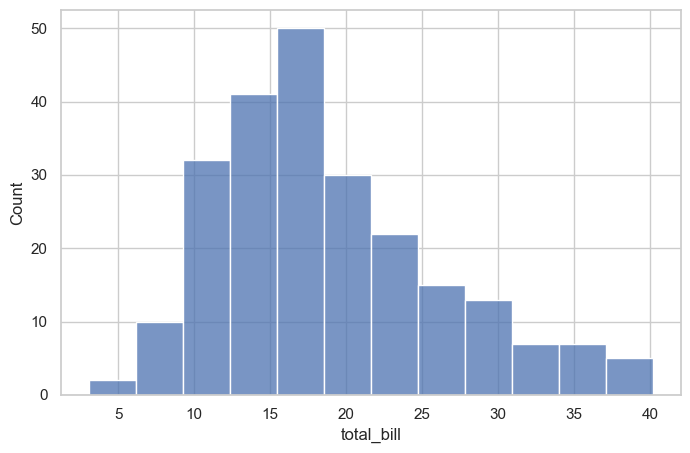

In [24]:
plt.figure(figsize=(8,5))
sns.histplot(df["total_bill"])
plt.savefig(r"C:\Users\moham\OneDrive\Desktop\data_science_project\outputs/bill_distribution.png")
plt.show()